In [4]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Connect to the BioCascade database
con = duckdb.connect('../data/processed/biocascade.db')
df = con.execute("SELECT * FROM raw_patient_data").df()

print(f"✅ Data Loaded: {df.shape[0]} patients and {df.shape[1]} clinical variables.")
df.head()

✅ Data Loaded: 5533 patients and 30 clinical variables.


,SEQN,age,gender,race_ethnicity,systolic_bp,diastolic_bp,bmi,waist_cm,height_cm,weight_kg,...,potassium,hscrp,hemoglobin,hematocrit,rdw,wbc_count,lymphocyte_pct,neutrophil_pct,ferritin,serum_iron
0,93705,66,2,4,NaN,NaN,31.7,101.8,158.3,79.5,...,4.0,2.72,11.9,36.7,15.6,8.6,40.0,48.8,28.7,92.0
1,93706,18,1,6,112.0,74.0,21.5,79.3,175.7,66.3,...,4.4,0.74,16.3,47.0,12.2,6.1,24.6,61.4,284.0,164.0
2,93708,66,2,6,NaN,NaN,23.7,88.2,150.2,53.5,...,4.4,1.83,13.2,39.9,13.4,6.0,31.3,59.4,109.0,90.0
3,93709,75,2,4,120.0,66.0,38.9,113.0,151.1,88.8,...,4.1,6.94,15.4,45.5,15.7,7.2,25.8,66.1,129.0,63.0
4,93711,56,1,6,108.0,68.0,21.3,86.6,170.6,62.1,...,4.9,0.82,14.7,43.2,13.3,5.0,35.5,53.0,40.6,56.0


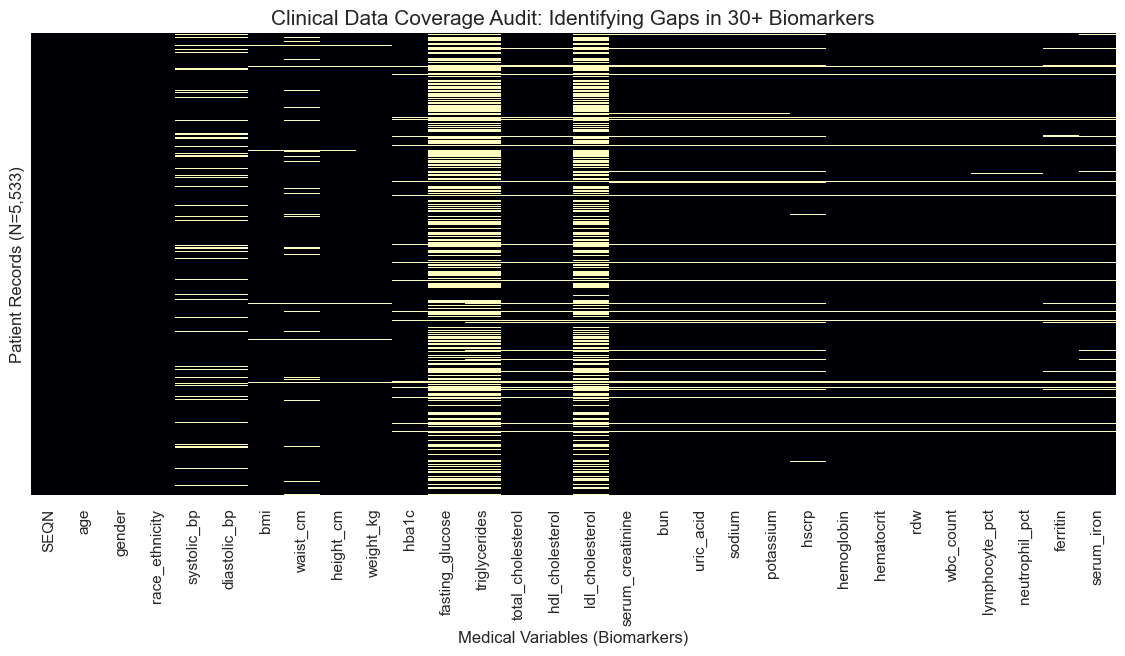

In [5]:
plt.figure(figsize=(14, 6))
# Creating a heatmap of missing values
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='magma')

plt.title('Clinical Data Coverage Audit: Identifying Gaps in 30+ Biomarkers', fontsize=15)
plt.xlabel('Medical Variables (Biomarkers)', fontsize=12)
plt.ylabel('Patient Records (N=5,533)', fontsize=12)
plt.show()

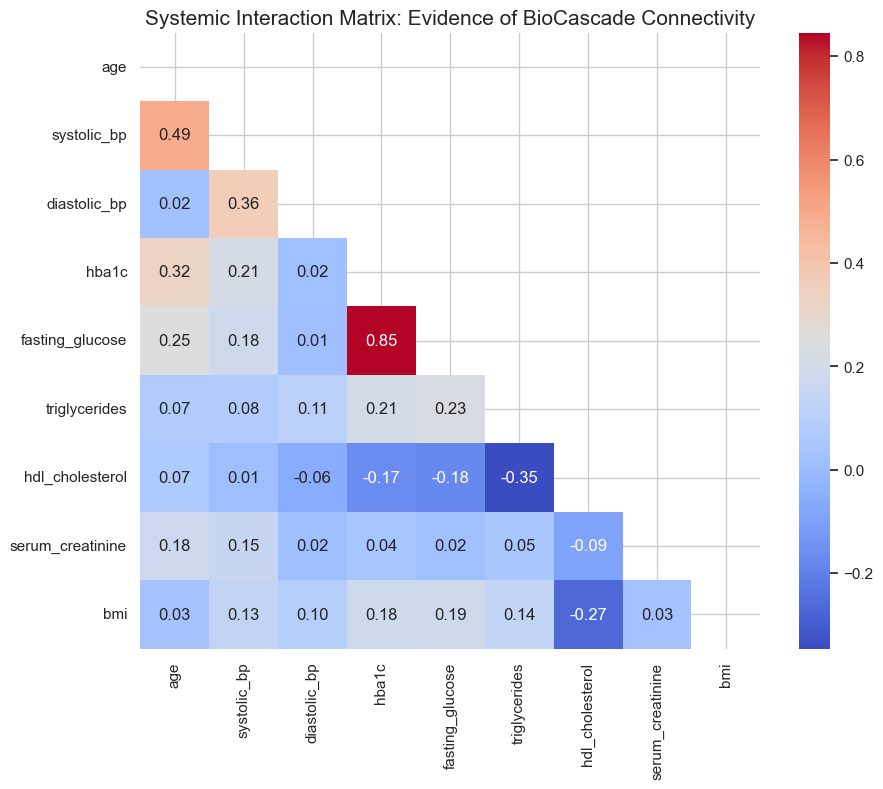

In [6]:
# Selection of core biomarkers representing the three systems
cascade_features = [
    'age', 'systolic_bp', 'diastolic_bp', 'hba1c', 
    'fasting_glucose', 'triglycerides', 'hdl_cholesterol', 
    'serum_creatinine', 'bmi'
]

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df[cascade_features].corr(), dtype=bool))
sns.heatmap(df[cascade_features].corr(), mask=mask, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Systemic Interaction Matrix: Evidence of BioCascade Connectivity', fontsize=15)
plt.show()

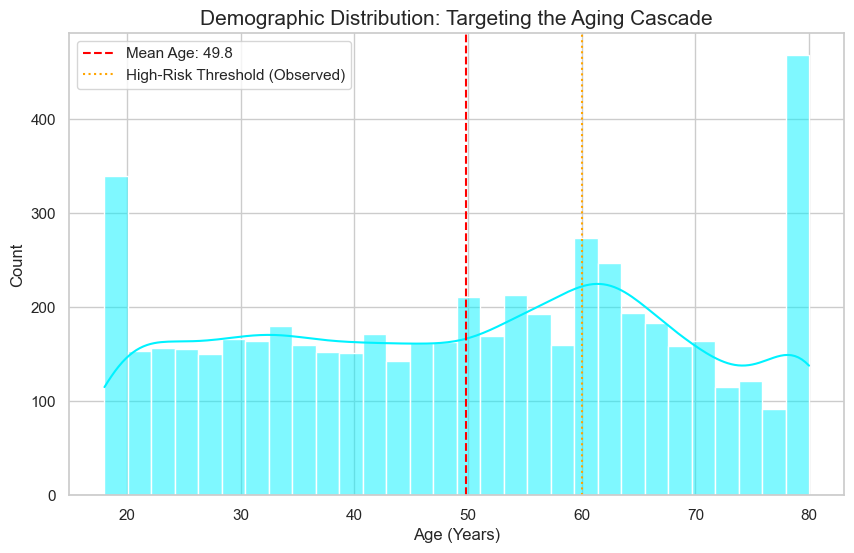

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=30, kde=True, color='#00f2ff')

plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean Age: {df["age"].mean():.1f}')
plt.axvline(60, color='orange', linestyle=':', label='High-Risk Threshold (Observed)')

plt.title('Demographic Distribution: Targeting the Aging Cascade', fontsize=15)
plt.xlabel('Age (Years)')
plt.legend()
plt.show()

In [8]:
# Statistical summary of the primary biomarkers
stats = df[['systolic_bp', 'diastolic_bp', 'hba1c', 'triglycerides', 'serum_creatinine']].describe()
print("📋 Clinical Range Audit:")
stats

📋 Clinical Range Audit:


,systolic_bp,diastolic_bp,hba1c,triglycerides,serum_creatinine
count,4899.000000,4899.000000,5261.000000,2493.000000,5154.000000
mean,125.984895,71.654623,5.837179,112.292820,0.901861
std,19.728263,13.561105,1.086560,102.467726,0.468275
min,72.000000,0.000000,3.800000,10.000000,0.250000
25%,112.000000,64.000000,5.300000,61.000000,0.700000
50%,124.000000,72.000000,5.600000,92.000000,0.840000
75%,136.000000,80.000000,6.000000,134.000000,1.000000
max,228.000000,136.000000,16.200000,2684.000000,12.740000


In [ ]:
def create_table1(df):
    summary = {'Characteristic': [], 'Value': []}
    
    # Demographics
    summary['Characteristic'].append('Age (years), mean ± SD')
    summary['Value'].append(f"{df['age'].mean():.1f} ± {df['age'].std():.1f}")
    
    # Note: gender 2 is usually Female in NHANES
    female_count = (df['gender'] == 2).sum()
    female_pct = (female_count / len(df)) * 100
    summary['Characteristic'].append('Female, n (%)')
    summary['Value'].append(f"{female_count} ({female_pct:.1f}%)")
    
    # Biomarkers (Using your exact DB names)
    metrics = [
        ('BMI (kg/m²)', 'bmi'),
        ('HbA1c (%)', 'hba1c'),
        ('Systolic BP (mmHg)', 'systolic_bp'),
        ('Diastolic BP (mmHg)', 'diastolic_bp'),
        ('Serum Creatinine (mg/dL)', 'serum_creatinine')
    ]
    
    for label, col in metrics:
        if col in df.columns:
            summary['Characteristic'].append(f"{label}, mean ± SD")
            summary['Value'].append(f"{df[col].mean():.2f} ± {df[col].std():.2f}")

    return pd.DataFrame(summary)

print("📊 TABLE 1: Clinical Baseline")
print(create_table1(df).to_string(index=False))